In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import TwoSlopeNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

#Balance migratorio

##Cargamos lo datos a utilisar

In [ ]:
df = pd.read_csv("fuentes_de_datos/migras_90_24.csv")

In [ ]:
def plot_balance_migratorio(año, df, otro=False):
    """año = año para el que se quiere el balance migratorio
    df = dataframe con datos de migración
    otro = año para comparar (opcional)"""

    # Tomamos todos los ISO3 que aparezcan como origen o destino
    paises = set(df['iso3_orig'].dropna()) | set(df['iso3_des'].dropna())

    # Eliminar código inválido
    paises.discard("ZZZ")

    balance_dict = {pais: 0 for pais in paises}
    balance_dict_otro = {pais: 0 for pais in paises}
    for _, row in df.iterrows():
        if row['año'] == año: 
            iso_orig = row['iso3_orig']
            iso_dest = row['iso3_des']
            migrantes = row['migrantes']
            if pd.isna(migrantes):
                continue
            if iso_orig != "ZZZ" and iso_orig in balance_dict:
                balance_dict[iso_orig] -= migrantes
            if iso_dest != "ZZZ" and iso_dest in balance_dict:
                balance_dict[iso_dest] += migrantes
        elif otro is not False and row['año'] == otro:
            iso_orig = row['iso3_orig']
            iso_dest = row['iso3_des']
            migrantes = row['migrantes']
            if pd.isna(migrantes):
                continue
            if iso_orig != "ZZZ" and iso_orig in balance_dict:
                balance_dict_otro[iso_orig] -= migrantes
            if iso_dest != "ZZZ" and iso_dest in balance_dict:
                balance_dict_otro[iso_dest] += migrantes
    if otro is False:
        balance_dict_otro = balance_dict

    #Preparar mapa
    fig = plt.figure(figsize=(20,12))
    ax = plt.axes(projection=ccrs.Robinson())
    ax.set_global()
    ax.set_facecolor("#f0f0f0")
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.4)
    cmap = plt.cm.RdYlGn

    # Normalización para compara entre dos fechas
    vmin = min(min(balance_dict.values()), min(balance_dict_otro.values()))
    vmax = max(max(balance_dict.values()), max(balance_dict_otro.values()))
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    cmap = plt.cm.RdYlGn

    #Leer shapefile Natural Earth
    shapefile = shpreader.natural_earth(
        resolution='110m',
        category='cultural',
        name='admin_0_countries'
    )


    #Dibujar países
    reader = shpreader.Reader(shapefile)
    for country in reader.records():
        iso3 = country.attributes['ISO_A3']
        geom = country.geometry
        if iso3 == "-99":
            continue
        value = balance_dict.get(iso3)
        if value is not None:
            facecolor = cmap(norm(value))
        else:
            facecolor = "#d3d3d3" 
        ax.add_geometries(
            [geom],
            ccrs.PlateCarree(),
            facecolor=facecolor,
            edgecolor="black",
            linewidth=0.2
        )
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.05, pad=0.02,shrink=0.8)
    # cbar.ax.set_position([0.80, 0.23, 0.02, 0.52])
    #cbar.set_label("Migrantes (1990)", fontsize=12)

    plt.title("Migrantes por país de origen (1990)", fontsize=18)
    plt.savefig(
        f"resultados/balance_migratorio_{año}.png",
        dpi=100,                 # calidad alta para impresión
        bbox_inches="tight",     # elimina márgenes blancos
        pad_inches=0.1,
        facecolor=fig.get_facecolor()
    )
    print(f"Mapa guardado como: resultados/balance_migratorio_{año}.png")
    plt.show()

##Comparamos el balace migratorio entr 1990 y 2024

Mapa guardado como: resultados/balance_migratorio_1990.png


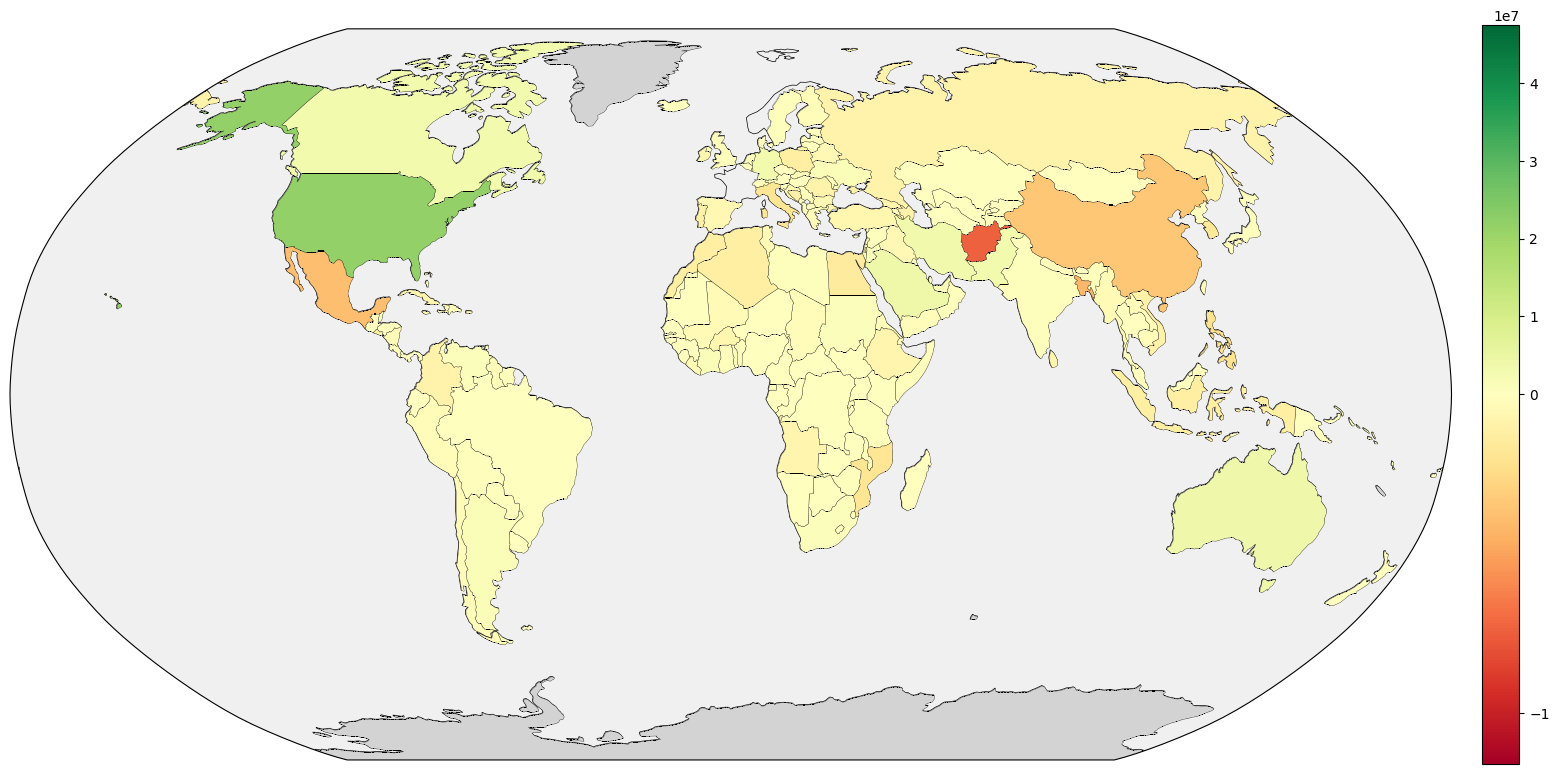

In [ ]:
plot_balance_migratorio(1990, df, 2024)
plot_balance_migratorio(2024, df, 1990)

#Migraiones Culturales

##Cargamos lo datos a utilisar

In [ ]:
pais_colono_idioma = pd.read_csv("fuentes_de_datos/idiomas_coloniales.csv")
migraciones = pd.read_csv("fuentes_de_datos/migras_90_24.csv")

##Combinamos las bases de datos y filtramos lo que no vamos a usar

In [ ]:
migraciones = migraciones[migraciones["region_orig_EN"]=="Africa"]
migraciones = migraciones[migraciones["iso3_orig"].isin(pais_colono_idioma["codigo_pais"])]
df = migraciones.merge(pais_colono_idioma, left_on="iso3_orig", right_on="codigo_pais")
df = df.merge(pais_colono_idioma, left_on="iso3_des",
              right_on="codigo_pais",
              suffixes=("_origen", "_destino"), how="left")

##Graficamos para los didtintos años las migraciones segun su destino

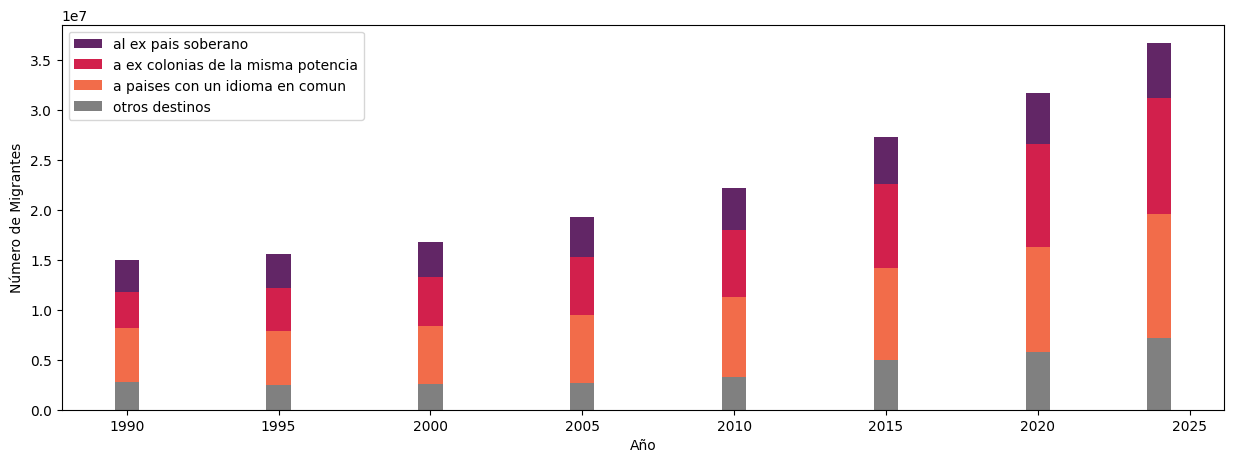

In [ ]:
migrantes = {"a_soberano": [], "otra_colonia": [], "mismo_idioma": [], "total": []}

años = [1990,1995,2000,2005,2010,2015,2020,2024]
for año in años:
    df_anio = df[df["año"] == año]
    a_soberano = df_anio[df_anio["iso3_des"] == df_anio["codigo_colonia_de_origen"]]
    otra_colonia = df_anio[df_anio["codigo_colonia_de_destino"] == df_anio["codigo_colonia_de_origen"]]
    mismo_idioma = df_anio[ ((df_anio["ingles_origen"] == df_anio["ingles_destino"]) | (df_anio["frances_origen"] == df_anio["frances_destino"]) | (df_anio["portugues_origen"] == df_anio["portugues_destino"]) | (df_anio["aleman_origen"] == df_anio["aleman_destino"]) | (df_anio["italiano_origen"] == df_anio["italiano_destino"]) | (df_anio["espanol_origen"] == df_anio["espanol_destino"]))]

    migrantes["a_soberano"].append(int(a_soberano["migrantes"].sum()))
    migrantes["otra_colonia"].append(int(otra_colonia["migrantes"].sum()))
    migrantes["mismo_idioma"].append(int(mismo_idioma["migrantes"].sum()))
    migrantes["total"].append(int(df_anio["migrantes"].sum()))
    
a_soberano = np.array(migrantes["a_soberano"])
otra_colonia = np.array(migrantes["otra_colonia"])
mismo_idioma = np.array(migrantes["mismo_idioma"])
total = np.array(migrantes["total"])

a = total-mismo_idioma
b = mismo_idioma-otra_colonia-a_soberano
c = otra_colonia
d = a_soberano


fig = plt.figure(figsize=(15,5))
plt.bar(años, d, label="al ex pais soberano", bottom=c+b+a , color="#622666")
plt.bar(años, c, label="a ex colonias de la misma potencia", bottom=b+a , color="#d2204c")
plt.bar(años, b, label="a paises con un idioma en comun", bottom=a, color="#f26c4a")
plt.bar(años, a, label="otros destinos", color="grey")
plt.xlabel("Año")
plt.ylabel("Número de Migrantes")
plt.legend()

plt.savefig(
    f"resultados/Migraciones culturales en africah.png",
    dpi=150,                 
    bbox_inches="tight",    
    pad_inches=0.1,
    facecolor=fig.get_facecolor()
)
plt.show()